# Topology Optimization of Binary Structures (TOBS)

## Transformer flux maximization — same problem as BESO notebook

**Reference:**  
> Sivapuram, R., & Picelli, R. (2018).  
> *Topology optimization of binary structures using Integer Linear Programming.*  
> Finite Elements in Analysis and Design, 139, 49–61.  
> (101-line MATLAB reference: https://github.com/rsivapuram/TOBS)

---

### What is TOBS?

TOBS (Topology Optimization of Binary Structures) is a **discrete 0/1 optimization** method.  
Like BESO, each element is either **material (1)** or **void (0)** — no intermediate grey values.  
Unlike BESO (heuristic threshold rules), TOBS solves a **Integer Linear Program (ILP)** at each iteration:

$$
\min_{\mathbf{x} \in \{0,1\}^N} \quad \mathbf{s}^\top \mathbf{x}
\quad \text{s.t.} \quad \mathbf{v}^\top \mathbf{x} \leq V^*, \quad |\mathbf{x} - \mathbf{x}^{(k)}|_1 \leq \Delta
$$

where $\mathbf{s}$ is the sensitivity vector, $\mathbf{v}$ are element volumes, $V^*$ is the volume target, and $\Delta$ controls the maximum number of element switches per iteration (the **move limit**).

The ILP is efficiently solved by relaxing to LP (since the constraint matrix is totally unimodular), meaning the LP solution is automatically integer-valued.

## 1) Geometry — same mesh as BESO

In [1]:
###############################################################################
## CODE CELL 1 : Import transformer mesh  (identical to BESO notebook)
###############################################################################

from geometry import transformer
from ngsolve.webgui import Draw

mesh = transformer(maxh=1e-2)                    # mesh the transformer geometry
print(f"Region names : {mesh.GetMaterials()}")   # display the regions (materials) labels
print(f"Line names   : {mesh.GetBoundaries()}")  # display the lines (boundaries) labels
Draw(mesh)

Region names : ('Omega_c', 'Pp', 'Pm', 'Sm', 'Sp')
Line names   : ('dOmega', 'dOmega', 'dOmega', 'dOmega', 'dPp', 'dPp', 'dPp', 'dPp', 'dPm', 'dPm', 'dPm', 'dPm', 'dSm', 'dSm', 'dSm', 'dSm', 'dSp', 'dSp', 'dSp', 'dSp')


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

## 2) Magnetostatic problem — same as BESO

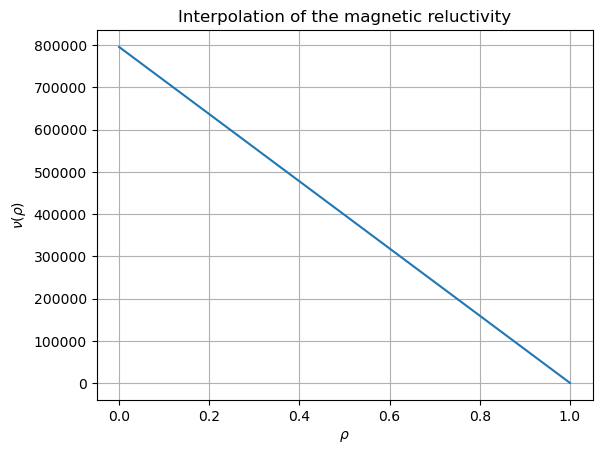

In [2]:
###############################################################################
## CODE CELL 2 : Reluctivity interpolation  (identical to BESO notebook)
###############################################################################

from numpy import pi
import numpy as np
import matplotlib.pyplot as plt

mu0 = 4e-7 * pi   # magnetic permeability of air (H/m)
mur = 1000        # relative magnetic permeability of iron
p   = 1           # SIMP exponent (p=1 → linear, keeps nu smooth for ILP sensitivity)

def nu(rho, p=1):
    """Reluctivity depending on density (power-law interpolation)."""
    return 1/mu0 + rho**p * (1/(mu0*mur) - 1/mu0)

rho_plot = np.linspace(0, 1, 100)
plt.plot(rho_plot, nu(rho_plot, p))
plt.xlabel(r"$\rho$"); plt.ylabel(r"$\nu(\rho)$")
plt.title("Interpolation of the magnetic reluctivity")
plt.grid(); plt.show()

In [3]:
###############################################################################
## CODE CELL 3 : Magnetostatic FEM solver  (identical to BESO notebook)
###############################################################################

j = 1e6  # current density in primary coil (A/m²)

from ngsolve import CF, grad, H1, BilinearForm, LinearForm, dx
from solver import solve

def curl(v):
    R = CF(((0,1),(-1,0)), dims=(2,2))  # rotation matrix of angle -pi/2
    return R * grad(v)

def state(rho):
    """Solve the magnetostatic state equation for a given density field rho."""
    fes = H1(mesh, order=1, dirichlet="dOmega")
    a, v = fes.TnT()
    bf = BilinearForm(curl(v) * (nu(rho) * curl(a)) * dx)
    lf = LinearForm(j * v * dx("Pp") - j * v * dx("Pm"))
    return solve(bf, lf)

# Test: solve with rho=0 (pure air)
a_rho, Kinv = state(0)
Draw(a_rho)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

## 3) Objective function & adjoint problem — same as BESO

In [4]:
###############################################################################
## CODE CELL 4 : Objective — maximize secondary flux  (identical to BESO)
###############################################################################

from solver import flux

def f(sol):
    """Objective to MINIMIZE: negative flux (so maximizing flux = minimizing -flux)."""
    return -flux(sol)

print(f" f(a_rho) = {f(a_rho):.5e} Wb/m   (negative = good direction)")

 f(a_rho) = -9.67796e-04 Wb/m   (negative = good direction)


In [5]:
###############################################################################
## CODE CELL 5 : Adjoint problem  (identical to BESO notebook)
###############################################################################

from optimization import solve_adjoint
from ngsolve import GridFunction, L2

def df(a, rho, aStar):
    """Directional derivative of objective w.r.t. the state a, in direction aStar."""
    return aStar*dx("Sm") - aStar*dx("Sp")

# Test with rho=0 density
rho_test = GridFunction(L2(mesh, definedon="Omega_c"))   # zero density (air)
p_rho = solve_adjoint(a_rho, rho_test, Kinv, df)
Draw(p_rho)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

## 4) Sensitivity computation — same formula as BESO

The elemental sensitivity for both BESO and TOBS comes from the adjoint method:

$$
s_e = \frac{\partial f}{\partial \rho_e} = \int_{\Omega_e} \nabla \times p \cdot \frac{\partial \nu}{\partial \rho} \nabla \times a \, d\Omega
$$

**This sensitivity computation is *identical* in both BESO and TOBS.**  
The difference comes entirely in *how those sensitivities are used to update the design*.

In [6]:
from ngsolve import LinearForm, dx, CF
from solver import curl

dnu_drho = CF(1/(mu0*mur) - 1/mu0)   # d(nu)/d(rho) for p=1 linear interpolation

def f_prime(state_gf, adjoint_gf, rho):
    """Elemental directional derivative of f w.r.t rho."""
    fes   = rho.space
    drho  = fes.TestFunction()
    lform = LinearForm(fes)
    lform += curl(adjoint_gf) * (dnu_drho * curl(state_gf)) * drho * dx
    lform.Assemble()
    return lform

def f_derivative(a_rho, rho, Kinv):
    """Full sensitivity GridFunction (adjoint + chain rule)."""
    p_rho   = solve_adjoint(a_rho, rho, Kinv, df)
    grad_gf = GridFunction(rho.space)
    grad_gf.vec.data = f_prime(a_rho, p_rho, rho).vec
    return grad_gf

# Test
rho_test = GridFunction(L2(mesh, definedon="Omega_c"))
Draw(f_derivative(a_rho, rho_test, Kinv))

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

In [7]:
###############################################################################
## CODE CELL 7 : Helper — compute sensitivity + objective in one call
###############################################################################

def compute_sensitivity(rho):
    """Run FEA, compute objective and sensitivity vector."""
    u, Kinv   = state(rho)
    obj_val   = f(u)                                         # scalar objective
    sens_gf   = f_derivative(u, rho, Kinv)                  # elemental sensitivities
    sens_vec  = sens_gf.vec.FV().NumPy()[:].copy()
    return obj_val, sens_vec, u

## 5) Volume / mass constraint — same as BESO

In [8]:
###############################################################################
## CODE CELL 8 : Volume fraction helpers  (identical to BESO)
###############################################################################

from ngsolve import Integrate

def m(rho, zone="Omega_c"):
    """Volume fraction of rho over the design domain."""
    return Integrate(rho*dx(zone), mesh) / Integrate(1, mesh, definedon=mesh.Materials(zone))

---
## 6) Algorithm comparison: BESO vs TOBS

This is the **key difference** between the two methods.

| Aspect | BESO | TOBS |
|---|---|---||
| **Design variables** | Binary $x_e \in \{0,1\}$ | Binary $x_e \in \{0,1\}$ |
| **Update rule** | Heuristic threshold on sensitivities | ILP: solve a Linear Program |
| **Volume control** | Implicit (count added/removed elements) | Explicit inequality constraint in LP |
| **Move limit** | Implicit via `add_precision`, `remove_precision` | Explicit $\ell^1$ constraint $\|\mathbf{x}-\mathbf{x}^k\|_1 \leq \Delta$ |
| **Oscillation handling** | Memory list of recently changed elements | LP move-limit naturally prevents large swings |
| **Theoretical basis** | Heuristic (no guarantee of improvement) | Each step minimizes linearized objective |
| **Sensitivity averaging** | Optional (BESO uses history averaging) | Recommended (stabilizes LP solution) |

### BESO update rule (heuristic)
Sort elements by sensitivity; flip the lowest-sensitivity solid elements to void and highest-sensitivity void elements to solid, using threshold ratios $RR$ and $IR$ that evolve to drive towards the volume target.

### TOBS update rule (ILP)
At each iteration, solve:
$$
\min_{\mathbf{x} \in [0,1]^N} \; \mathbf{s}^\top \mathbf{x}
\quad\text{s.t.}\quad
\mathbf{v}^\top \mathbf{x} \leq V^*, \quad
x_e - x_e^{(k)} \leq t_e, \quad
x_e^{(k)} - x_e \leq t_e, \quad
\mathbf{1}^\top \mathbf{t} \leq \Delta, \quad
t_e \geq 0
$$
Because the constraint matrix is **totally unimodular**, the LP relaxation always yields a $\{0,1\}$ solution — no branch-and-bound needed.

## 7) TOBS — Integer Linear Program update step

We use `scipy.optimize.linprog` (HiGHS backend) to solve the LP at each iteration.

In [9]:
###############################################################################
## CODE CELL 9 : TOBS ILP update  (core difference w.r.t. BESO)
###############################################################################

import numpy as np
from scipy.optimize import linprog

def tobs_update(x_current, sens, eVol, V_target, delta):
    """
    TOBS design update via Linear Programming.
    
    Solves the LP relaxation (totally unimodular → integer solution guaranteed):
    
        min   s^T x
        s.t.  v^T x  <=  V_target          (volume constraint)
              sum(t)  <=  delta             (move limit)
              x - x0 <=  t                 (define |x - x0| via t)
              x0 - x <=  t
              0 <= x <= 1,  t >= 0

    Parameters
    ----------
    x_current : ndarray (N,) — current binary design
    sens      : ndarray (N,) — elemental sensitivities df/drho
    eVol      : ndarray (N,) — normalized element volumes
    V_target  : float        — volume fraction target (e.g. 0.3)
    delta     : int          — max elements allowed to switch (move limit)
    
    Returns
    -------
    x_new : ndarray (N,) — updated binary design
    """
    N  = len(x_current)
    x0 = x_current.copy()

    # Variables: z = [x (N), t (N)]  with t = |x - x0|  (auxiliary)
    # Objective: minimize s^T x  →  c = [s, 0...0]
    c = np.concatenate([sens, np.zeros(N)])

    # Inequality constraints  A_ub @ z <= b_ub
    # 1) Volume constraint: sum(eVol * x) <= V_target
    #    [ eVol | 0 ] @ z <= V_target
    A_vol = np.hstack([eVol[np.newaxis, :], np.zeros((1, N))])
    b_vol = np.array([V_target])

    # 2) Move limit: sum(t) <= delta
    #    [ 0...0 | 1...1 ] @ z <= delta
    A_move = np.hstack([np.zeros((1, N)), np.ones((1, N))])
    b_move = np.array([float(delta)])

    # 3)  x - x0 <= t  →  [ I | -I ] @ z <= x0
    A_t1 = np.hstack([ np.eye(N), -np.eye(N)])
    b_t1 = x0

    # 4)  x0 - x <= t  →  [-I | -I ] @ z <= -x0
    A_t2 = np.hstack([-np.eye(N), -np.eye(N)])
    b_t2 = -x0

    A_ub = np.vstack([A_vol, A_move, A_t1, A_t2])
    b_ub = np.concatenate([b_vol, b_move, b_t1, b_t2])

    # Bounds: 0 <= x <= 1,  t >= 0
    bounds = [(0, 1)] * N + [(0, None)] * N

    # Solve LP (HiGHS is fast and handles 1000s of variables easily)
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

    if not res.success:
        raise RuntimeError(f"LP failed: {res.message}")

    x_new = np.round(res.x[:N]).astype(float)   # should already be {0,1} by TU property
    return x_new

### Sensitivity history averaging (Picelli & Sivapuram, Eq. 9)

To stabilize the LP solution and reduce oscillations, the sensitivity is averaged over the last two iterations:

$$
\tilde{s}_e^{(k)} = \frac{s_e^{(k)} + s_e^{(k-1)}}{2}
$$

This is a standard technique also used in BESO.

## 8) TOBS main optimization loop

In [10]:
###############################################################################
## CODE CELL 10 : Initialization — identical mesh setup as BESO
###############################################################################

from ngsolve import GridFunction, L2, Integrate
import numpy as np

# Build mask to identify design-domain elements
V0 = Integrate(1, mesh, definedon=mesh.Materials("Omega_c"))
mask = GridFunction(L2(mesh, definedon=mesh.Materials("Omega_c")))
mask.Set(1)
maskOmega_c   = mask.vec.FV().NumPy()[:] >= 0.9   # boolean mask over ALL dofs
N_triangles   = int(np.sum(maskOmega_c))

# Normalized element volumes (sum = 1 over design domain)
eVol_all = Integrate(1, mesh, definedon=mesh.Materials("Omega_c"), element_wise=True).NumPy()[:] / V0
eVol     = eVol_all[maskOmega_c]

print(f"Number of design elements: {N_triangles}")
print(f"Sum of normalized element volumes: {eVol.sum():.4f}  (should be ≈1)")

Number of design elements: 7748
Sum of normalized element volumes: 1.0000  (should be ≈1)


In [11]:
###############################################################################
## CODE CELL 11 : TOBS hyperparameters
###############################################################################

# ── Target volume fraction (same as BESO surf_ratio)
V_target   = 0.10    # 10% volume of design domain filled with iron

# ── Move limit: max number of element switches per iteration
# Picelli recommends delta ~ 2-5% of N_triangles
delta_frac = 0.05    # 5% of elements can switch per iteration
delta      = max(1, int(delta_frac * N_triangles))

# ── Iteration budget
N_max      = 100

# ── Convergence: stop if no elements switch for `patience` iterations
patience   = 5

print(f"Volume target  : {V_target*100:.1f}%")
print(f"Move limit Δ   : {delta} elements per iteration ({delta_frac*100:.0f}% of {N_triangles})")

Volume target  : 10.0%
Move limit Δ   : 387 elements per iteration (5% of 7748)


In [12]:
###############################################################################
## CODE CELL 12 : TOBS optimization loop
###############################################################################

from ngsolve.webgui import Draw
from copy import copy

# ── Initialize design: start from void (xval = 0 everywhere)
rho_tobs = GridFunction(L2(mesh, definedon="Omega_c"))
xval     = np.zeros(N_triangles)   # 0 = air, 1 = iron
rho_tobs.vec.data.FV().NumPy()[maskOmega_c] = xval

scene = Draw(rho_tobs, mesh, min=0, max=1)

# ── History lists
MemObjective   = []
MemVolume      = []
MemSwitches    = []
sens_prev      = None       # for history averaging
no_change_cnt  = 0

print("Starting TOBS optimization...")
print(f"{'Iter':>5} | {'Objective':>12} | {'Volume %':>9} | {'Switches':>9}")
print("-" * 46)

for loop in range(1, N_max + 1):

    # ── 1) FEA + sensitivity
    obj_val, sens_all, u_sol = compute_sensitivity(rho_tobs)
    sens = sens_all[maskOmega_c]                   # extract design-domain sensitivities

    # ── 2) Sensitivity history averaging (Picelli Eq. 9)
    if sens_prev is not None:
        sens_avg = 0.5 * (sens + sens_prev)
    else:
        sens_avg = sens.copy()
    sens_prev = sens.copy()

    # Record metrics
    current_vol = float(np.dot(eVol, xval))
    MemObjective.append(obj_val)
    MemVolume.append(current_vol)

    # ── 3) TOBS ILP update  ← **KEY DIFFERENCE FROM BESO**
    xval_new = tobs_update(xval, sens_avg, eVol, V_target, delta)

    # ── 4) Count switches and check convergence
    n_switches = int(np.sum(xval_new != xval))
    MemSwitches.append(n_switches)

    xval = xval_new.copy()
    rho_tobs.vec.data.FV().NumPy()[maskOmega_c] = xval

    # ── 5) Visualize
    scene.Redraw()

    print(f"{loop:5d} | {obj_val:12.5e} | {current_vol*100:9.2f} | {n_switches:9d}")

    # ── 6) Convergence check
    if n_switches == 0:
        no_change_cnt += 1
        if no_change_cnt >= patience:
            print(f"\nConverged: no element switched for {patience} consecutive iterations.")
            break
    else:
        no_change_cnt = 0

print(f"\nTOBS finished after {loop} iterations.")
u_final, _ = state(rho_tobs)
print(f"Final flux  = {flux(u_final):.5e} Wb/m")
print(f"Final vol   = {m(rho_tobs)*100:.3f}%")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

Starting TOBS optimization...
 Iter |    Objective |  Volume % |  Switches
----------------------------------------------
    1 | -9.67796e-04 |      0.00 |       143
    2 | -9.91092e-03 |      2.09 |       387
    3 | -5.13492e+00 |      7.70 |       182
    4 | -6.19369e+00 |     10.00 |        24
    5 | -6.30099e+00 |     10.00 |         2
    6 | -6.33141e+00 |     10.00 |         2
    7 | -6.34312e+00 |     10.01 |         0
    8 | -6.34312e+00 |     10.01 |         0
    9 | -6.34312e+00 |     10.01 |         0
   10 | -6.34312e+00 |     10.01 |         0
   11 | -6.34312e+00 |     10.01 |         0

Converged: no element switched for 5 consecutive iterations.

TOBS finished after 11 iterations.
Final flux  = 6.34312e+00 Wb/m
Final vol   = 10.007%


## 9) Results: convergence curves

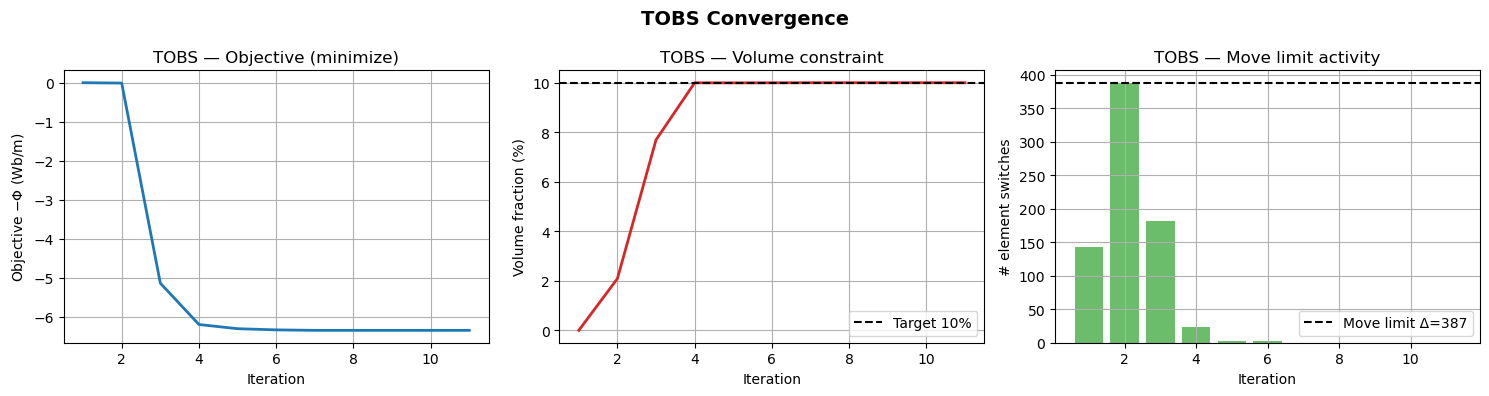

In [13]:
###############################################################################
## CODE CELL 13 : Convergence plots
###############################################################################

import matplotlib.pyplot as plt
import numpy as np

iters = np.arange(1, len(MemObjective) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# — Objective (negative flux)
axes[0].plot(iters, MemObjective, color='tab:blue', lw=2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective $-\\Phi$ (Wb/m)")
axes[0].set_title("TOBS — Objective (minimize)")
axes[0].grid(True)

# — Volume fraction
axes[1].plot(iters, [v*100 for v in MemVolume], color='tab:red', lw=2)
axes[1].axhline(V_target*100, color='k', ls='--', label=f'Target {V_target*100:.0f}%')
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Volume fraction (%)")
axes[1].set_title("TOBS — Volume constraint")
axes[1].legend()
axes[1].grid(True)

# — Switches per iteration
axes[2].bar(iters, MemSwitches, color='tab:green', alpha=0.7)
axes[2].axhline(delta, color='k', ls='--', label=f'Move limit Δ={delta}')
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("# element switches")
axes[2].set_title("TOBS — Move limit activity")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("TOBS Convergence", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ###############################################################################
# ## Helper: mass derivative (from prof's CODE CELL 10)
# ###############################################################################

# def m_derivative(rho):
#     """Riesz representer of the mass gradient."""
#     fes  = rho.space
#     drho = fes.TestFunction()
#     mprime = LinearForm(fes)
#     mprime += drho * dx("Omega_c")
#     mprime.Assemble()
#     riesz = GridFunction(rho.space)
#     riesz.vec.data = mprime.vec
#     return riesz

In [15]:
# rho_test = GridFunction(L2(mesh, definedon="Omega_c"))
# rho_test.Set(0.5)
# sol_test, _ = state(rho_test)
# print(f"flux at rho=0.5     : {flux(sol_test):.3e}")
# print(f"penalty at rho=0.5  : {0.5*(0.5-0.1)**2:.3e}")
# beta = flux(sol_test) / (0.5*(0.5-0.1)**2) * 10
# print(beta)

In [16]:
        # ###############################################################################
        # ## SIMP — exact copy of prof's CODE CELLS 11 + 12
        # ###############################################################################

        # from ngsolve import GridFunction, L2
        # from optimization import gradient_descent, solve_adjoint
        # import numpy as np

        # # ── Prof's df (CODE CELL 5) — redefine to match prof's Ns/Lz/Sp/Sm version ──
        # Ns = 100
        # Lz = 1
        # from ngsolve import Integrate
        # Sp = Integrate(1, mesh, definedon=mesh.Materials("Sp"))
        # Sm = Integrate(1, mesh, definedon=mesh.Materials("Sm"))

        # def df_simp(state_gf, rho, a):
        #     """Prof's exact df — note the Ns*Lz/Sp and /Sm scaling."""
        #     return -Ns * Lz * (a/Sp * dx("Sp") - a/Sm * dx("Sm"))

        # # ── Prof's f_prime (CODE CELL 6) — using nu(rho).Diff(rho) ──────────────────
        # def f_prime_simp(state_gf, adjoint_gf, rho):
        #     fes  = rho.space
        #     drho = fes.TestFunction()
        #     lform = LinearForm(fes)
        #     # d(nu)/d(rho) = (1/(mu0*mur) - 1/mu0) for p=1, this is a constant
        #     dnu = 1/(mu0*mur) - 1/mu0
        #     lform += curl(adjoint_gf) * (dnu * curl(state_gf)) * drho * dx
        #     lform.Assemble()
        #     return lform

        # # ── Prof's descent function (CODE CELL 8) ────────────────────────────────────
        # def descent_plain(F_prime, P=lambda x: x):
        #     d = GridFunction(F_prime.space)
        #     d.vec.data -= P(F_prime.vec)   # d = -F_prime  (starts from zero vec)
        #     return d

        # # ── Prof's penalized objective (CODE CELL 11) ────────────────────────────────
        # m0   = 0.1
        # beta = 1

        # def f_penalized(rho, sol=None):
        #     if sol is None:
        #         sol, _ = state(rho)
        #     return -flux(sol) + beta/2 * max(0, m(rho) - m0)**2

        # def f_penalized_derivative(a_rho, rho, Kinv):
        #     v_rho = solve_adjoint(a_rho, rho, Kinv, df_simp)
        #     riesz = GridFunction(rho.space)
        #     riesz.vec.data = (f_prime_simp(a_rho, v_rho, rho).vec
        #                     + beta * max(0, m(rho) - m0) * m_derivative(rho).vec)
        #     return riesz

        # # ── Prof's run (CODE CELL 12) ─────────────────────────────────────────────────
        # rho_simp = GridFunction(L2(mesh, definedon="Omega_c"))
        # rho_simp.Set(0.5)

        # results_simp = gradient_descent(
        #     state       = state,
        #     objective   = f_penalized,
        #     d_objective = f_penalized_derivative,
        #     x0          = rho_simp,
        #     descent     = lambda x: descent_plain(x),   # plain descent, no sign
        #     step        = 1,
        #     x_min       = 0,
        #     x_max       = 1,
        #     maxit       = 200,
        #     tol         = 1e-6,
        #     step_min    = 1e-10,
        #     draw        = True,
        #     verbose     = 2
        # )

        # rho_simp_final = results_simp["solution"][-1]
        # u_simp_final, _ = state(rho_simp_final)
        # print(f"SIMP → flux = {flux(u_simp_final):.5e} Wb/m  |  vol = {m(rho_simp_final)*100:.2f}%")

---
## BESO Optimization
BESO (Bi-directional Evolutionary Structural Optimization) is a **binary** method like TOBS — $\rho_e \in \{0,1\}$ only. Elements are added or removed based on heuristic sensitivity thresholds, with a memory list to prevent oscillations. No LP is solved — the update is purely rank-based.

In [17]:
###############################################################################
## BESO optimization — heuristic threshold update
###############################################################################

from ngsolve import GridFunction, L2, Integrate
from ngsolve.webgui import Draw
import numpy as np

rho_beso = GridFunction(L2(mesh, definedon="Omega_c"))
xval_beso = np.zeros(N_triangles)
rho_beso.vec.data.FV().NumPy()[maskOmega_c] = xval_beso

# BESO parameters
surf_ratio       = 0.10
surf_precision   = 0.999
add_precision    = 0.1
remove_precision = 0.1
init_factor      = 0.8
N_max_beso       = 100

modified      = list(range(N_triangles))
current_surf  = 0.0
loop_beso     = 0

MemObjective_BESO  = []
MemVolume_BESO     = []

obj_beso, sens_all_beso, _ = compute_sensitivity(rho_beso)
delta_B = np.concatenate([[obj_beso], sens_all_beso])

scene_beso = Draw(rho_beso, mesh, min=0, max=1)

print(f"{'Iter':>5} | {'Objective':>12} | {'Volume %':>9} | {'Add':>5} | {'Remove':>7}")
print("-" * 50)

while (current_surf < 1 * surf_ratio * surf_precision or
       current_surf > 1 * surf_ratio) and loop_beso < N_max_beso:

    MemObjective_BESO.append(delta_B[0])
    MemVolume_BESO.append(current_surf)

    loop_beso += 1
    ratio = abs(current_surf / surf_ratio - 1.0)

    if current_surf > surf_ratio:
        init_factor    = 1.1
        surf_precision -= 0.1
    if current_surf < surf_ratio * surf_precision and init_factor == 1.1:
        init_factor    = 0.9
        surf_precision -= 0.1

    add_nbr    = round(add_precision    * ratio * N_triangles)
    remove_nbr = round(remove_precision * init_factor * ratio * N_triangles)

    if add_nbr == remove_nbr:
        if current_surf > surf_ratio:
            remove_nbr += 1
        else:
            add_nbr += 1

    sens = -delta_B[1:]
    sens = sens[maskOmega_c]

    modified_mask = np.zeros(N_triangles, dtype=bool)
    modified_mask[modified] = True

    candidates_add    = np.where( modified_mask)[0]
    candidates_remove = np.where(~modified_mask)[0]

    if add_nbr > 0 and len(candidates_add) > 0:
        top_add = candidates_add[np.argsort(sens[candidates_add])[-add_nbr:]]
        xval_beso[top_add] = 1.0
        modified_mask[top_add] = False

    if remove_nbr > 0 and len(candidates_remove) > 0:
        top_remove = candidates_remove[np.argsort(sens[candidates_remove])[:remove_nbr]]
        xval_beso[top_remove] = 0.0
        modified_mask[top_remove] = True

    modified = list(np.where(modified_mask)[0])

    rho_beso.vec.data.FV().NumPy()[maskOmega_c] = xval_beso

    obj_beso, sens_all_beso, _ = compute_sensitivity(rho_beso)
    delta_B = np.concatenate([[obj_beso], sens_all_beso])

    current_surf = float(np.dot(eVol, xval_beso))
    scene_beso.Redraw()

    print(f"{loop_beso:5d} | {obj_beso:12.5e} | {current_surf*100:9.2f} | {add_nbr:5d} | {remove_nbr:7d}")

u_beso, _ = state(rho_beso)
print(f"\nBESO finished after {loop_beso} iterations.")
print(f"Final flux = {flux(u_beso):.5e} Wb/m  |  Final vol = {m(rho_beso)*100:.3f}%")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

 Iter |    Objective |  Volume % |   Add |  Remove
--------------------------------------------------
    1 | -6.14356e+00 |     11.34 |   775 |     620
    2 | -5.82635e+00 |     11.06 |   104 |     114
    3 | -5.89909e+00 |     11.02 |    82 |      91
    4 | -5.85089e+00 |     10.86 |    79 |      87
    5 | -5.87357e+00 |     10.76 |    66 |      73
    6 | -5.93034e+00 |     10.68 |    59 |      65
    7 | -5.93318e+00 |     10.61 |    53 |      58
    8 | -5.93468e+00 |     10.53 |    47 |      52
    9 | -5.94283e+00 |     10.48 |    41 |      45
   10 | -5.94113e+00 |     10.39 |    37 |      41
   11 | -5.95961e+00 |     10.35 |    30 |      33
   12 | -5.96431e+00 |     10.31 |    27 |      30
   13 | -6.01741e+00 |     10.26 |    24 |      26
   14 | -6.01760e+00 |     10.24 |    20 |      22
   15 | -6.01741e+00 |     10.22 |    19 |      20
   16 | -6.02761e+00 |     10.20 |    17 |      18
   17 | -6.02370e+00 |     10.19 |    16 |      17
   18 | -6.03138e+00 |     10.1

---
## Final Comparison: SIMP vs BESO vs TOBS

In [18]:
# ###############################################################################
# ## Comparison: convergence curves + final topologies
# ###############################################################################

# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np

# fig = plt.figure(figsize=(18, 10))
# gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# # ── Row 1: convergence curves ──────────────────────────────────────────────

# # Objective
# ax1 = fig.add_subplot(gs[0, 0])
# #ax1.plot(results_simp["objective"],  label="SIMP", color="tab:green",  lw=2)
# ax1.plot(MemObjective_BESO,          label="BESO", color="tab:orange", lw=2)
# ax1.plot(MemObjective,               label="TOBS", color="tab:blue",   lw=2)
# ax1.set_xlabel("Iteration"); ax1.set_ylabel("Objective $-\\Phi$ (Wb/m)")
# ax1.set_title("Objective convergence"); ax1.legend(); ax1.grid()

# # Volume fraction
# ax2 = fig.add_subplot(gs[0, 1])
# # SIMP: compute volume history
# #simp_vol_history = [float(m(x)) for x in results_simp["solution"]]
# #ax2.plot(simp_vol_history,           label="SIMP", color="tab:green",  lw=2)
# ax2.plot([v*100 for v in MemVolume_BESO], label="BESO", color="tab:orange", lw=2)
# ax2.plot([v*100 for v in MemVolume],      label="TOBS", color="tab:blue",   lw=2)
# ax2.axhline(10, color='k', ls='--', label="Target 10%")
# ax2.set_xlabel("Iteration"); ax2.set_ylabel("Volume fraction (%)")
# ax2.set_title("Volume constraint"); ax2.legend(); ax2.grid()

# # Number of iterations bar chart
# ax3 = fig.add_subplot(gs[0, 2])
# methods = [ "BESO", "TOBS"]
# n_iters = [len(results_simp["objective"]), loop_beso, len(MemObjective)]
# colors  = ["tab:green", "tab:orange", "tab:blue"]
# bars = ax3.bar(methods, n_iters, color=colors, alpha=0.8)
# for bar, val in zip(bars, n_iters):
#     ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
#              str(val), ha='center', va='bottom', fontweight='bold')
# ax3.set_ylabel("# iterations"); ax3.set_title("Iterations to converge"); ax3.grid(axis='y')

# # ── Row 2: summary table ───────────────────────────────────────────────────

# ax4 = fig.add_subplot(gs[1, :])
# ax4.axis('off')

# #u_simp_final, _ = state_simp(rho_simp_final)
# #flux_simp = flux(u_simp_final)
# flux_beso = flux(u_beso)
# flux_tobs = flux(u_final)

# #vol_simp  = m(rho_simp_final) * 100
# vol_beso  = m(rho_beso)       * 100
# vol_tobs  = m(rho_tobs)       * 100

# table_data = [
#     ["Method",    "Final flux (Wb/m)",       "Final volume (%)", "# Iterations", "Update rule",           "Variables"],
# #    ["SIMP",      f"{flux_simp:.5e}",         f"{vol_simp:.2f}",  str(len(results_simp['objective'])), "Gradient descent",  "Continuous [0,1]"],
#     ["BESO",      f"{flux_beso:.5e}",         f"{vol_beso:.2f}",  str(loop_beso),                      "Heuristic threshold","Binary {0,1}"],
#     ["TOBS",      f"{flux_tobs:.5e}",         f"{vol_tobs:.2f}",  str(len(MemObjective)),               "Linear Program",    "Binary {0,1}"],
# ]

# col_widths = [0.08, 0.18, 0.16, 0.14, 0.22, 0.18]
# x_pos = np.cumsum([0] + col_widths[:-1])

# for row_idx, row in enumerate(table_data):
#     for col_idx, (cell, x) in enumerate(zip(row, x_pos)):
#         weight = 'bold' if row_idx == 0 else 'normal'
#         color  = ['#f0f0f0', 'white'][row_idx % 2] if row_idx > 0 else '#d0d0d0'
#         ax4.text(x + col_widths[col_idx]/2, 1 - row_idx*0.18, cell,
#                  transform=ax4.transAxes, ha='center', va='top',
#                  fontsize=10, fontweight=weight,
#                  bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='gray'))

# ax4.set_title("Summary comparison", fontsize=12, fontweight='bold', pad=10)

# plt.suptitle(" BESO vs TOBS — Transformer flux maximization",
#              fontsize=14, fontweight='bold')
# plt.show()

## 10) Side-by-side comparison: BESO vs TOBS

Run the following cell **after** you have run the BESO notebook and have `MemObjective_BESO` and `MemConstraint_BESO` available, or adapt it to load saved results.

In [19]:
###############################################################################
## Final topologies side by side
###############################################################################

from ngsolve.webgui import Draw

# print("── SIMP final topology (continuous densities) ──")
# Draw(rho_simp_final, mesh, min=0, max=1)
print("── BESO final topology (binary) ──")
Draw(rho_beso, mesh, min=0, max=1)
print("── TOBS final topology (binary) ──")
Draw(rho_tobs, mesh, min=0, max=1)

── BESO final topology (binary) ──


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

── TOBS final topology (binary) ──


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

In [20]:
###############################################################################
## CODE CELL 16 : Magnetic vector potential in optimized design
###############################################################################

Draw(u_final)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': '6.2.2201', 'mesh_dim': 2,…

BaseWebGuiScene

---
## Summary: BESO vs TOBS — algorithm and code differences

### What is the same
- Mesh, geometry, boundary conditions (cells 1–3)
- Objective function: maximize secondary flux (cell 4)
- Adjoint problem formulation (cell 5)
- Sensitivity formula: $s_e = \int_{\Omega_e} \nabla\times p \cdot \frac{d\nu}{d\rho} \nabla\times a \, d\Omega$ (cell 6)
- Design space: binary $\rho_e \in \{0,1\}$

### What is different: the update step

**BESO** (heuristic, ~20 lines):
```python
# Sort by sensitivity; add top-k, remove bottom-k based on threshold ratios
top_add    = candidates_add[np.argsort(sens[candidates_add])[-add_nbr:]]
top_remove = candidates_remove[np.argsort(sens[candidates_remove])[:remove_nbr]]
xval[top_add]    = 1.0
xval[top_remove] = 0.0
```
*Parameters to tune*: `add_precision`, `remove_precision`, `init_factor`, `surf_precision`  
*No volume constraint guarantee per step*

---

**TOBS** (LP-based, `tobs_update` function):
```python
# Solve LP:  min s^T x  s.t.  v^T x <= V_target,  ||x - x0||_1 <= delta
res  = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
xval = np.round(res.x[:N])   # TU property → always integer
```
*Parameters to tune*: `delta` (move limit), `V_target`  
*Volume constraint is satisfied exactly at every iteration*

### Key takeaways
1. **TOBS is more principled**: each iteration minimizes a linearized version of the objective subject to the exact volume constraint.
2. **TOBS is easier to parameterize**: only one main hyperparameter (`delta`) versus several in BESO.
3. **Both produce similar final topologies** for the same problem, but TOBS tends to converge more monotonically.
4. **TOBS can be slower per iteration** (LP solve) but requires fewer iterations to converge.